#
해당문서는 colab 에서 실행 했음

In [2]:
#%pip install -U "opentelemetry-api==1.42.1" "opentelemetry-sdk==1.42.1"

In [3]:
%pip install -Uqqq langchain langchain-openai langchain-chroma


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 2.7.1 requires opentelemetry-api<=1.42.1,>=1.39, but you have opentelemetry-api 1.44.0 which is incompatible.
google-adk 2.7.1 requires opentelemetry-sdk<=1.42.1,>=1.39, but you have opentelemetry-sdk 1.44.0 which is incompatible.


In [4]:
# 구글 드라이브 마운트 및 뎐동
from google.colab import drive # Colab에서 구글드라이브 사용 모듈
drive.mount('/content/drive') # 현재 런타임에서 내 구글드라이브 마운트 (연동)

BASE_PATH = '/content/drive/MyDrive/skn_34/05_multimodal_rag'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import os
from google.colab import userdata

os.environ['OPENAI_API_KEY'] = userdata.get('OPENAI_API_KEY')
os.environ['LANGSMITH_TRACING'] = 'true'
os.environ['LANGSMITH_ENDPOINT'] = 'https://api.smith.langchain.com'
os.environ['LANGSMITH_PROJECT'] = 'skn34-langchain'
os.environ['LANGSMITH_API_KEY'] = userdata.get('LANGSMITH_API_KEY')

# 이미지 캡셔닝 & 벡터db 저장

In [6]:
# 이미지 파일을 Base64 문자열로 변환하는 함수
import base64   # 바이너리 데이터 <-> Base64 인코딩/디코딩
from PIL import Image

def image_to_base64(image_path):
  with open(image_path, 'rb') as f: # 파일을 바이너리 읽기 모드로 열기
    encoded = base64.b64encode(f.read()).decode('utf-8') # base64 인코딩 후 문자열로 변환
  return encoded

image_to_base64(f'{BASE_PATH}/figures/figure-1.jpg')

'...'

In [7]:
from openai import OpenAI

client = OpenAI()

def surmmarize_image(image_path):
  encoded = image_to_base64(image_path)

  response = client.chat.completions.create(
      model = 'gpt-5.6-luna',
      messages = [
          {
                'role': 'system',
                'content': '''
아래 아미지를 안전교육 및 화재대피 관점에서
주제문구와 각 장면에 대한 정보를 빠짐없이 한국어로 설명해주세요.
'''  # 모델에게 부여하는 지침(역할 및 설명 방식 정의)
            },
            {
                'role': 'user',
                'content': [{
                    'type': 'image_url',  # 이미지 입력 타입 지정
                    'image_url': {
                        'url': f'data:image/jpeg;base64,{encoded}'  # Base64 인코딩된 이미지 전달
                    }
                }]
            }
      ]
  )
  return response.choices[0].message.content # 생성한 답변 텍스트
print(surmmarize_image(f'{BASE_PATH}/figures/figure-1.jpg'))

## 이미지 주제

- **주제문구:** 완강기 사용 방법  
- **영문 표기:** *FIRE ESCAPE DEVICE*  
- **주제 설명:** 화재나 비상 상황에서 건물의 창문 등을 통해 완강기를 이용해 안전하게 아래층이나 지상으로 대피하는 방법을 안내하는 안전교육 자료입니다.
- 그림은 완강기 사용 절차를 **① 고정 ② 릴 투척 ③ 안전벨트 착용 ④ 벽을 향해 하강**하는 4단계로 설명합니다.

---

## 장면 1. 후크를 고리에 안전하게 건다

- **안내 문구:**  
  - 한국어: “1. 후크를 고리에 안전하게 건다.”  
  - 영어: “Hang the Hook to the eyebolt safely.”
- **장면 설명:** 완강기의 **후크**를 건물 벽이나 창가에 설치된 **고리(아이볼트)**에 걸고 있습니다.
- **안전 의미:** 하강하기 전에 완강기가 움직이지 않도록 고정 지점에 후크를 확실히 연결해야 합니다.
- **주의사항:**
  - 후크가 고리에 완전히 걸렸는지 확인합니다.
  - 고정 고리나 설치 부분이 흔들리거나 손상되지 않았는지 확인합니다.
  - 난간, 창틀 등 고정력이 불확실한 곳에는 임의로 걸지 않습니다.
  - 후크를 제대로 연결하지 않으면 하강 중 장비가 빠져 추락할 위험이 있습니다.

---

## 장면 2. 릴을 창밖으로 던진다

- **안내 문구:**  
  - 한국어: “2. 릴(줄)을 창밖으로 던진다.”  
  - 영어: “Throw the reel out of the window.”
- **장면 설명:** 완강기에 연결된 **릴과 로프를 창문 밖으로 내보내거나 던지는** 모습입니다. 그림에는 창밖으로 릴이 내려가고, 아래쪽에 로프가 풀리는 모습이 표시되어 있습니다.
- **안전 의미:** 로프가 건물 외부로 충분히 내려가야 사람이 건물 밖에서 벽을 따라 하강할 수 있습니다.
- **주의사항:**
  - 릴이나 로프가 창틀, 난간, 구조물에 걸리지 않았는지 확인합니다.
  - 아래에 사람이 있거나

In [8]:
# vector db 구축
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings
from tqdm.auto import tqdm
import os

parsistent_dir = f'{BASE_PATH}/chroma' # 백테DB 저장 경로

embeddings = OpenAIEmbeddings(model='text-embedding-3-small')
vector_db = Chroma(
    collection_name = 'multimodal_rag', # 컬렉션(테이블) 이름
    embedding_function = embeddings,    # 사용할 임베딩 함수
    persist_directory = parsistent_dir  # 저장할 경로
)

In [9]:
# 이미지 목록 생성 및 캡션 기반 VectorDB 저장
figure_dir = os.path.join(BASE_PATH, 'figures') # figures 폴더

image_files = [
    os.path.join(figure_dir, filename)
    for filename in os.listdir(figure_dir) if filename.lower().endswith(('png', 'jpg', 'jpeg')) # 확장자가 이미지 파일이면

]

for img_path in tqdm(image_files):
  b64_str = image_to_base64(img_path)
  caption = surmmarize_image(img_path)

  vector_db.add_texts(
      texts = [caption], # 이미지 요약
      metadatas = [{
          'base64_image': b64_str, # 원본 이미지
          'image_path': img_path  # 파일 경로
      }]
  )

vector_db

  0%|          | 0/1 [00:00<?, ?it/s]

In [10]:
# vector DB 데이터 조회
docs = vector_db._collection.get() # Chroma DB 컬렉션에 저장된 전체 문서 / 메타데이터 조회

for i, (page_content, metadata) in enumerate(zip(docs['documents'], docs['metadatas'])):
  print(f"{i+1}번 :")
  print(f"page_content = {page_content}") # page_content = {page_content}
  print(f"metadata = {metadata}")
  print()

1번 :
page_content = ## 이미지 주제

**「완강기 사용 방법」 / “FIRE ESCAPE DEVICE”**  
화재 등 비상 상황에서 건물 창문에 설치된 **완강기(하강식 피난기구)**를 이용해 안전하게 지상으로 대피하는 방법을 안내하는 그림입니다.

이미지는 빨간색 배경에 흰색 안내판이 배치되어 있으며, 완강기 사용 절차를 **총 4단계**로 설명하고 있습니다.

---

## 1단계: 후크를 고리에 안전하게 건다

- **한국어 문구:**  
  **“1. 후크를 고리에 안전하게 건다.”**
- **영어 문구:**  
  **“Hang the Hook to the eyebolt safely.”**
- **장면 설명:**  
  완강기의 금속 후크를 건물에 고정된 **아이볼트(고정 고리)**에 걸고 있는 모습입니다.
- **안전 의미:**  
  후크가 고리에 제대로 걸리지 않으면 하강 중 장비가 빠질 수 있으므로, 후크가 고정 고리에 완전히 체결되었는지 확인해야 합니다.
- **주의사항:**  
  고리가 흔들리거나 손상되지 않았는지 확인하고, 후크가 걸린 상태에서 무리하게 당겨 고정 상태를 점검하는 것이 좋습니다.

---

## 2단계: 릴 또는 줄을 창밖으로 던진다

- **한국어 문구:**  
  **“2. 리릴(줄)을 창밖으로 던진다.”**  
  ※ 이미지의 글자는 다소 흐리지만, 의미상 완강기의 **릴 또는 연결 줄**을 창밖으로 내보내라는 안내입니다.
- **영어 문구:**  
  **“Throw the reel out of the window.”**
- **장면 설명:**  
  사람이 창가에서 완강기 줄과 릴 부분을 창밖으로 던지고 있습니다. 그림 아래에는 창문턱과 바깥쪽으로 내려가는 줄이 표현되어 있습니다.
- **안전 의미:**  
  하강 장치의 줄이 건물 밖으로 충분히 펼쳐져야 사람이 벽면을 따라 내려갈 수 있습니다.
- **주의사항:**  
  줄이 창틀, 난간, 돌출물 등에 걸리지 않았는지 확인해야 합니다. 아

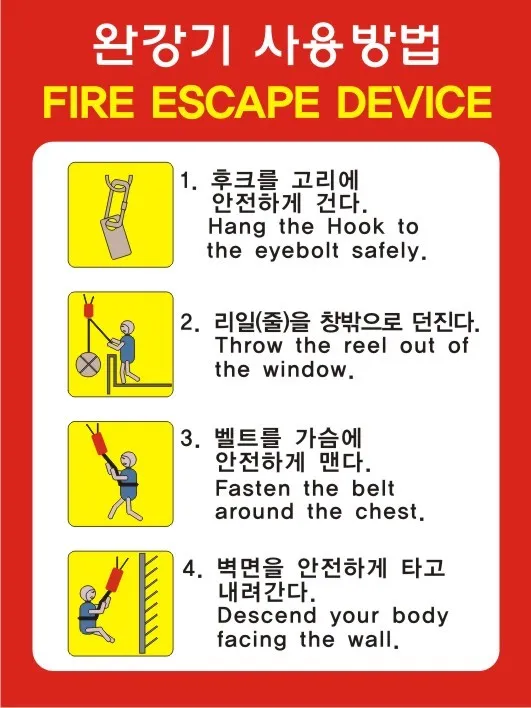

In [11]:
# base64 이미지를 화면에 출력
from io import BytesIO
from PIL import Image

def show_base64_image(b64_str):
  img = Image.open(BytesIO(base64.b64decode(b64_str))) # base64 디코딩 후 이미지 객체형식으로 생성
  display(img)
show_base64_image(docs['metadatas'][0]['base64_image'])


1 : ## 이미지 주제문구

- **상단 제목:** 「완강기 사용 방법」
- **영문 제목:** **FIRE ESCAPE DEVICE**
- **의미:** 화재 등 비상 상황에서 건물의 높은 층에서 지상으로 대피할 때 사용하는 **완강기(하강식 피난기구)**의 기본 사용 순서를 안내하는 안전교육 자료입니다.
- 완강기는 로프와 조속기, 벨트 등을 이용해 사람이 급격히 떨어지지 않고 비교적 일정한 속도로 내려가도록 돕는 피난기구입니다.
- 다만 그림은 기본적인 사용 순서만 보여 주므로, 실제 사용 전에는 건물에 설치된 장비의 안내문과 소방·안전교육 내용을 반드시 확인해야 합니다.

---

## 1번 장면: 훅을 고리에 안전하게 건다

### 그림과 문구
- **한국어:** “1. 후크를 고리에 안전하게 건다.”
- **영어:** “Hang the Hook to the eyebolt safely.”
- 그림에는 완강기의 **금속 훅**을 벽이나 창가에 설치된 **고정 고리(아이볼트, eyebolt)**에 연결하는 모습이 나와 있습니다.

### 안전교육 내용
- 완강기를 사용하기 전에 훅을 건물에 고정된 **전용 고정 고리**에 정확히 걸어야 합니다.
- 훅이 고리에 완전히 걸렸는지, 걸쇠가 빠지지 않는지 눈으로 확인합니다.
- 난간, 창틀, 배관, 임의의 고리 등 튼튼하지 않거나 용도가 불분명한 곳에는 연결하면 안 됩니다.
- 고정 고리나 훅이 흔들리거나 손상되어 있으면 사용을 중지하고 다른 피난 방법을 찾아야 합니다.
- 훅을 연결한 뒤 로프가 꼬이지 않았는지, 창문이나 벽 모서리에 걸리지 않는지도 확인합니다.

---

## 2번 장면: 릴 또는 줄을 창밖으로 던진다

### 그림과 문구
- **한국어:** “2. 릴(줄)을 창밖으로 던진다.”
- **영어:** “Throw the reel out of the window.”
- 그림에는 훅을 고정한 뒤 완강기의 **릴과 로프를 창밖으로 내보내는 모습**이 표시되어 있습니다.

### 안전교육 내용
- 훅

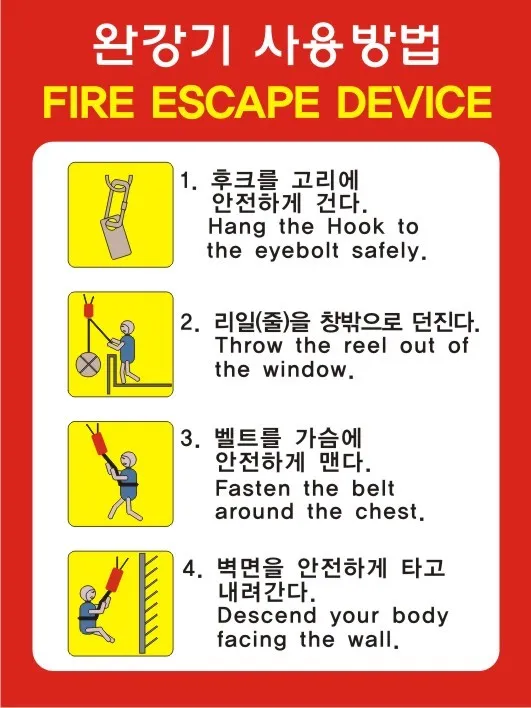

2 : ## 이미지 주제

**「완강기 사용 방법」 / “FIRE ESCAPE DEVICE”**  
화재 등 비상 상황에서 건물 창문에 설치된 **완강기(하강식 피난기구)**를 이용해 안전하게 지상으로 대피하는 방법을 안내하는 그림입니다.

이미지는 빨간색 배경에 흰색 안내판이 배치되어 있으며, 완강기 사용 절차를 **총 4단계**로 설명하고 있습니다.

---

## 1단계: 후크를 고리에 안전하게 건다

- **한국어 문구:**  
  **“1. 후크를 고리에 안전하게 건다.”**
- **영어 문구:**  
  **“Hang the Hook to the eyebolt safely.”**
- **장면 설명:**  
  완강기의 금속 후크를 건물에 고정된 **아이볼트(고정 고리)**에 걸고 있는 모습입니다.
- **안전 의미:**  
  후크가 고리에 제대로 걸리지 않으면 하강 중 장비가 빠질 수 있으므로, 후크가 고정 고리에 완전히 체결되었는지 확인해야 합니다.
- **주의사항:**  
  고리가 흔들리거나 손상되지 않았는지 확인하고, 후크가 걸린 상태에서 무리하게 당겨 고정 상태를 점검하는 것이 좋습니다.

---

## 2단계: 릴 또는 줄을 창밖으로 던진다

- **한국어 문구:**  
  **“2. 리릴(줄)을 창밖으로 던진다.”**  
  ※ 이미지의 글자는 다소 흐리지만, 의미상 완강기의 **릴 또는 연결 줄**을 창밖으로 내보내라는 안내입니다.
- **영어 문구:**  
  **“Throw the reel out of the window.”**
- **장면 설명:**  
  사람이 창가에서 완강기 줄과 릴 부분을 창밖으로 던지고 있습니다. 그림 아래에는 창문턱과 바깥쪽으로 내려가는 줄이 표현되어 있습니다.
- **안전 의미:**  
  하강 장치의 줄이 건물 밖으로 충분히 펼쳐져야 사람이 벽면을 따라 내려갈 수 있습니다.
- **주의사항:**  
  줄이 창틀, 난간, 돌출물 등에 걸리지 않았는지 확인해야 합니다. 아래에 사람이 있거나 장애물이 

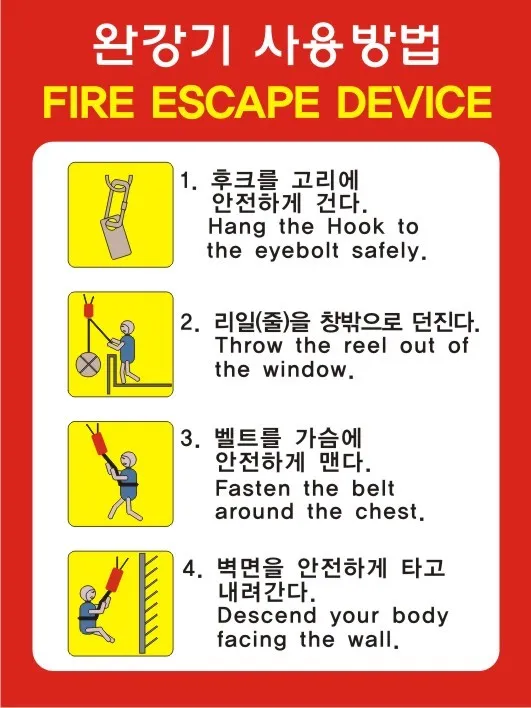

In [12]:
query = '완강기는 어떻게 써야하나?'
docs = vector_db.similarity_search(query, k=2) # 질문과 유사한 상위 2개 문서 검색

for i, doc in enumerate(docs):
  print(f"{i+1} : {doc.page_content}") # 캡셔 내용
  show_base64_image(doc.metadata['base64_image']) # 이미지 출력

# @title 기본 제목 텍스트
## Multimodal RAG 구현
- agentic rag 구현 (middleware기반 검색된 문서 제공)
- text + image 응답

In [14]:
from langchain.chat_models import init_chat_model # LLM 초기화
from langchain.agents import create_agent         # 에이전트 생성
from langchain.agents.middleware import AgentMiddleware, AgentState # 에이전트 미들웨어 / 상태 타입
from langchain_core.documents import Document     # 검색 결과 문서 타입
from typing import Any # 타입 힌트용

# 에이전트가 유지할 상태 스키마
class State(AgentState):
  context: list[Document]

# 모델 호출 전에 문서 검색 및 프롬프트 재작성 미들웨어
class RetrieverDocumentsMiddleware(AgentMiddleware[State]):
  state_schema = State # 이 미들웨어의 상태 스키마

  # 상태를 입력받아 출력이 {'messages': ...} 또는 None 반환
  def before_model(self, state:AgentState) -> dict[str, Any] | None:
    last_message = state['messages'][-1] # 사용자 메시지
    retriever_docs = vector_db.similarity_search(last_message.text, k=2) # 질문과 유사한 문서 2개

    docs_content = '\n\n'.join(doc.page_content for doc in retriever_docs) # 하나의 문자열로 합침

    prompt = f'''
    제공된 '참조 문서'의 내용을 바탕으로 '사용자 질문'에 대해 상세히 답변하라.

제약 조건:
- 답변은 반드시 제공된 문서 내의 정보만을 근거로 작성한다.
- 문서에서 답을 찾을 수 없는 경우, "제공된 정보에서는 해당 내용을 확인할 수 없습니다"라고 답변한다.
- 논리적이고 가독성이 좋게 구조화하여 설명한다.

참조 문서:
{docs_content}

사용자 질문:
{last_message.text}
    '''

    return {
        # 사용자 메시지를 프롬프트로 바꿔서 모델에 전달
        'messages': [last_message.model_copy(update={'content': prompt})],
        'context': retriever_docs # 검색된 문서 (상태 저장)
    }

## 화재 시 완강기 사용법

완강기는 화재 등 비상 상황에서 건물의 높은 층에서 지상으로 대피할 때 사용하는 하강식 피난기구입니다. 다만 계단이나 비상구를 안전하게 이용할 수 있다면 일반 피난통로를 우선 이용하고, 완강기는 마지막 대피 수단 중 하나로 사용해야 합니다.

### 1. 훅을 고정 고리에 건다

- 완강기의 금속 훅을 벽이나 창가에 설치된 전용 고정 고리, 즉 아이볼트에 정확히 겁니다.
- 훅이 고리에 완전히 걸렸는지, 걸쇠가 빠지지 않는지 확인합니다.
- 난간, 창틀, 배관 등 용도가 불분명하거나 튼튼하지 않은 곳에는 연결하지 않습니다.
- 고정 고리나 훅이 흔들리거나 손상되어 있으면 사용하지 않습니다.
- 로프가 꼬였거나 창문과 벽 모서리에 걸리지 않았는지도 확인합니다.

### 2. 릴과 로프를 창밖으로 내보낸다

- 훅을 고정한 뒤 완강기의 릴과 로프를 창밖으로 천천히 내보냅니다.
- 로프가 건물 외벽을 따라 아래로 곧게 펼쳐졌는지 확인합니다.
- 아래에 사람, 차량, 장애물, 돌출 구조물이 없는지 살핍니다.
- 아래에 사람이 있으면 “내려갑니다”라고 알려 안전한 곳으로 이동시키도록 합니다.
- 로프가 전선, 간판, 나뭇가지, 다른 창문 등에 걸렸다면 하강하지 말고 장애물을 제거하거나 다른 대피 방법을 선택합니다.

### 3. 벨트를 가슴에 단단히 착용한다

- 하강용 벨트를 가슴에 걸고 몸에 맞도록 조입니다.
- 벨트가 목이나 얼굴을 압박하지 않도록 하고, 겨드랑이 아래와 가슴 주변에 안정적으로 위치시킵니다.
- 버클과 연결부가 제대로 잠겼는지 확인합니다.
- 벨트를 허리에만 느슨하게 걸거나 한 손으로 잡고 내려가서는 안 됩니다.
- 가방, 끈, 장신구, 헐거운 옷 등이 벨트나 로프에 걸리지 않도록 정리합니다.

### 4. 벽을 바라보며 천천히 하강한다

- 창밖으로 나간 뒤 벽을 향한 자세를 유지하며 천천히 내려갑니다.
- 몸을 벽에서 너무 멀리 젖히지 말고, 발로 벽을 가볍게 지지해 흔들림을 줄입니다.
- 아래를 보며 급하게 움직

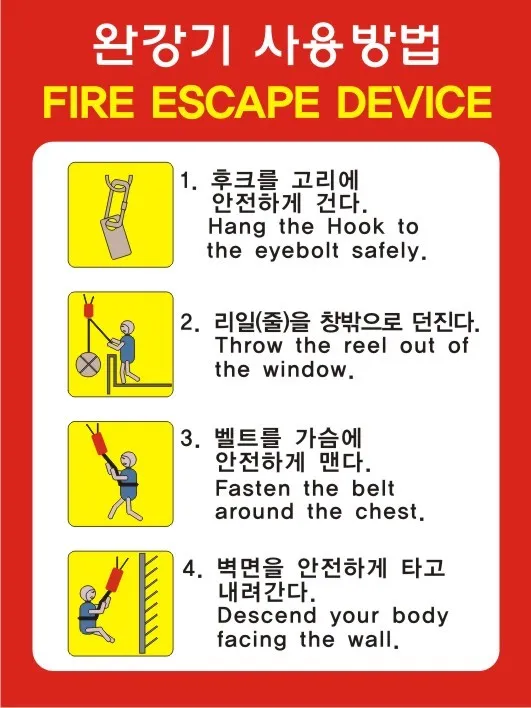

## 이미지 주제문구

- **상단 제목:** 「완강기 사용 방법」
- **영문 제목:** **FIRE ESCAPE DEVICE**
- **의미:** 화재 등 비상 상황에서 건물의 높은 층에서 지상으로 대피할 때 사용하는 **완강기(하강식 피난기구)**의 기본 사용 순서를 안내하는 안전교육 자료입니다.
- 완강기는 로프와 조속기, 벨트 등을 이용해 사람이 급격히 떨어지지 않고 비교적 일정한 속도로 내려가도록 돕는 피난기구입니다.
- 다만 그림은 기본적인 사용 순서만 보여 주므로, 실제 사용 전에는 건물에 설치된 장비의 안내문과 소방·안전교육 내용을 반드시 확인해야 합니다.

---

## 1번 장면: 훅을 고리에 안전하게 건다

### 그림과 문구
- **한국어:** “1. 후크를 고리에 안전하게 건다.”
- **영어:** “Hang the Hook to the eyebolt safely.”
- 그림에는 완강기의 **금속 훅**을 벽이나 창가에 설치된 **고정 고리(아이볼트, eyebolt)**에 연결하는 모습이 나와 있습니다.

### 안전교육 내용
- 완강기를 사용하기 전에 훅을 건물에 고정된 **전용 고정 고리**에 정확히 걸어야 합니다.
- 훅이 고리에 완전히 걸렸는지, 걸쇠가 빠지지 않는지 눈으로 확인합니다.
- 난간, 창틀, 배관, 임의의 고리 등 튼튼하지 않거나 용도가 불분명한 곳에는 연결하면 안 됩니다.
- 고정 고리나 훅이 흔들리거나 손상되어 있으면 사용을 중지하고 다른 피난 방법을 찾아야 합니다.
- 훅을 연결한 뒤 로프가 꼬이지 않았는지, 창문이나 벽 모서리에 걸리지 않는지도 확인합니다.

---

## 2번 장면: 릴 또는 줄을 창밖으로 던진다

### 그림과 문구
- **한국어:** “2. 릴(줄)을 창밖으로 던진다.”
- **영어:** “Throw the reel out of the window.”
- 그림에는 훅을 고정한 뒤 완강기의 **릴과 로프를 창밖으로 내보내는 모습**이 표시되어 있습니다.

### 안전교육 내용
- 훅을 안전

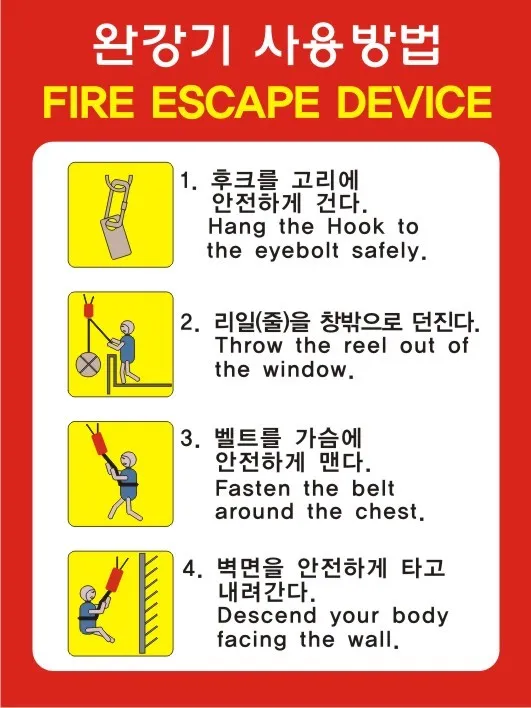

## 이미지 주제

**「완강기 사용 방법」 / “FIRE ESCAPE DEVICE”**  
화재 등 비상 상황에서 건물 창문에 설치된 **완강기(하강식 피난기구)**를 이용해 안전하게 지상으로 대피하는 방법을 안내하는 그림입니다.

이미지는 빨간색 배경에 흰색 안내판이 배치되어 있으며, 완강기 사용 절차를 **총 4단계**로 설명하고 있습니다.

---

## 1단계: 후크를 고리에 안전하게 건다

- **한국어 문구:**  
  **“1. 후크를 고리에 안전하게 건다.”**
- **영어 문구:**  
  **“Hang the Hook to the eyebolt safely.”**
- **장면 설명:**  
  완강기의 금속 후크를 건물에 고정된 **아이볼트(고정 고리)**에 걸고 있는 모습입니다.
- **안전 의미:**  
  후크가 고리에 제대로 걸리지 않으면 하강 중 장비가 빠질 수 있으므로, 후크가 고정 고리에 완전히 체결되었는지 확인해야 합니다.
- **주의사항:**  
  고리가 흔들리거나 손상되지 않았는지 확인하고, 후크가 걸린 상태에서 무리하게 당겨 고정 상태를 점검하는 것이 좋습니다.

---

## 2단계: 릴 또는 줄을 창밖으로 던진다

- **한국어 문구:**  
  **“2. 리릴(줄)을 창밖으로 던진다.”**  
  ※ 이미지의 글자는 다소 흐리지만, 의미상 완강기의 **릴 또는 연결 줄**을 창밖으로 내보내라는 안내입니다.
- **영어 문구:**  
  **“Throw the reel out of the window.”**
- **장면 설명:**  
  사람이 창가에서 완강기 줄과 릴 부분을 창밖으로 던지고 있습니다. 그림 아래에는 창문턱과 바깥쪽으로 내려가는 줄이 표현되어 있습니다.
- **안전 의미:**  
  하강 장치의 줄이 건물 밖으로 충분히 펼쳐져야 사람이 벽면을 따라 내려갈 수 있습니다.
- **주의사항:**  
  줄이 창틀, 난간, 돌출물 등에 걸리지 않았는지 확인해야 합니다. 아래에 사람이 있거나 장애물이 있는 경

In [17]:
llm = init_chat_model('gpt-5.6-luna')
agent = create_agent(
    llm,
    tools = [],
    middleware = {RetrieverDocumentsMiddleware()} # 모델 호출 전 검색 / 프롬프트 주입
)

response = agent.invoke({
    'messages': [
        ('human', '화재 시 완강기 사용법을 알려줘')
    ]
})

print(response['messages'][-1].content) # 모델 응다

print('[검색된 내용]')
for doc in response['context']:
  show_base64_image(doc.metadata['base64_image']) # 이미지 출력
  print(doc.page_content) # 캡션 내용